# Supply and Demand - Project 4 Capstone (Random Forest)
To forecast future demand based on past consumption records.  
To have a relatively accurate safety stocks and ROP to prevent stockout stituation.  


## Import Libraries and Read Dataset

In [1]:
import pandas as pd
import numpy as np 

df = pd.read_excel('./Dynamic Inventory Analytics/data_inputs.xlsx', sheet_name=None)
df_1 = pd.read_excel('./holidays_2021_2023.xlsx', sheet_name=None)

print(df.keys())
#To get the different sheets data from "Data_Inputs.XLSX"
Sheet1_df = df['Sales Data']
Sheet2_df = df['Inventory Control']
Sheet3_df = df['SKU Items']
Sheet4_df = df['Warehouse'] 
print(Sheet1_df)

#To get the different sheets data from "Holiday_2021_2023"
holiday_date = df_1['holidays_2021_2023']
company_country = df_1['Sheet1']

print(holiday_date)
print(company_country)
#Sheet1_df.drop(columns = ['Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12'], inplace = True)

dict_keys(['Sales Data', 'Inventory Control', 'SKU Items', 'Warehouse'])
      Order Number Order Date  SKU ID Warehouse ID Customer Type  \
0      SO - 018900 2021-01-01  3551CA       GUT930        Export   
1      SO - 018901 2021-01-01  3079BA       AXW291     Wholesale   
2      SO - 018902 2021-01-01  3250CA       AXW291   Distributor   
3      SO - 018903 2021-01-01  1161AA       GUT930     Wholesale   
4      SO - 018904 2021-01-01  3512AA       GUT930   Distributor   
...            ...        ...     ...          ...           ...   
33914  SO - 052814 2023-07-30  2528CA       NXH382     Wholesale   
33915  SO - 052815 2023-07-30  2336BA       AXW291     Wholesale   
33916  SO - 052816 2023-07-30  2371CA       AXW291   Distributor   
33917  SO - 052817 2023-07-30  1851CA       AXW291     Wholesale   
33918  SO - 052818 2023-07-30  3126BA       AXW291   Distributor   

       Order Quantity  Unit Sale Price  Revenue  
0          105.000000          7.06831      742  
1         

In [3]:
#Combining two files together to merge company name to the holiday dates, assuming that the company closed on these dates 
company_holiday = pd.merge(holiday_date, company_country, how = 'inner', on = 'Country')

print(company_holiday)

         Weekday                   Name                      Type Details  \
0         Friday         New Year's Day           Federal Holiday     NaN   
1         Friday         New Year's Day           Federal Holiday     NaN   
2         Friday         New Year's Day           Federal Holiday     NaN   
3         Friday         New Year's Day           Federal Holiday     NaN   
4         Friday         New Year's Day           Federal Holiday     NaN   
...          ...                    ...                       ...     ...   
18245     Sunday    Special Working Day  Working Day on a Weekend     NaN   
18246     Monday  Double Ninth Festival                Observance     NaN   
18247  Wednesday       Journalists' Day          Other Observance     NaN   
18248     Friday      December Solstice                    Season     NaN   
18249     Monday          Christmas Day                Observance     NaN   

             Country       Date   Company Name  
0      united states 2021-

**To convert the data to Month Year in order to do the Monthly Forecast Calculation**

In [6]:
Sheet1_df['Tranc_Mth_Yr'] = Sheet1_df['Order Date'].dt.to_period('M').dt.to_timestamp()

**To get the unique SKU ID and unique month year**

In [9]:
all_months = pd.date_range(start=Sheet1_df['Tranc_Mth_Yr'].min(), 
                           end=Sheet1_df['Tranc_Mth_Yr'].max(), 
                           freq='MS')  # MS = Month Start
all_skus = Sheet1_df['SKU ID'].unique()

In [11]:
Sheet1_df.shape
Sheet1_df.dtypes

Order Number               object
Order Date         datetime64[ns]
SKU ID                     object
Warehouse ID               object
Customer Type              object
Order Quantity            float64
Unit Sale Price           float64
Revenue                     int64
Tranc_Mth_Yr       datetime64[ns]
dtype: object

In [13]:
full_index = pd.MultiIndex.from_product([all_skus, all_months], names=['SKU ID', 'Tranc_Mth_Yr'])
full_df = pd.DataFrame(index=full_index).reset_index()

In [15]:
print(full_df)

      SKU ID Tranc_Mth_Yr
0     3551CA   2021-01-01
1     3551CA   2021-02-01
2     3551CA   2021-03-01
3     3551CA   2021-04-01
4     3551CA   2021-05-01
...      ...          ...
8985  1488BA   2023-03-01
8986  1488BA   2023-04-01
8987  1488BA   2023-05-01
8988  1488BA   2023-06-01
8989  1488BA   2023-07-01

[8990 rows x 2 columns]


**Merging of data to ensure that all SKU has data from Jan 2021 to Jul 2023**

In [18]:
data_df = pd.merge(left = full_df, right = Sheet1_df, how = 'left', on = ['SKU ID', 'Tranc_Mth_Yr'])
print (data_df) 

       SKU ID Tranc_Mth_Yr Order Number Order Date Warehouse ID Customer Type  \
0      3551CA   2021-01-01  SO - 018900 2021-01-01       GUT930        Export   
1      3551CA   2021-01-01  SO - 018908 2021-01-01       AXW291   Distributor   
2      3551CA   2021-01-01  SO - 018929 2021-01-01       GUT930     Wholesale   
3      3551CA   2021-01-01  SO - 018937 2021-01-01       AXW291     Wholesale   
4      3551CA   2021-01-01  SO - 019010 2021-01-03       AXW291   Distributor   
...       ...          ...          ...        ...          ...           ...   
36050  1488BA   2023-03-01  SO - 051199 2023-03-18       AXW291   Distributor   
36051  1488BA   2023-04-01          NaN        NaT          NaN           NaN   
36052  1488BA   2023-05-01          NaN        NaT          NaN           NaN   
36053  1488BA   2023-06-01          NaN        NaT          NaN           NaN   
36054  1488BA   2023-07-01          NaN        NaT          NaN           NaN   

       Order Quantity  Unit

**To fill up NaN columns with actual Year and Month**

In [21]:
data_df['Year'] = data_df['Tranc_Mth_Yr'].dt.year
data_df['Month'] = data_df['Tranc_Mth_Yr'].dt.month
data_df.dtypes

SKU ID                     object
Tranc_Mth_Yr       datetime64[ns]
Order Number               object
Order Date         datetime64[ns]
Warehouse ID               object
Customer Type              object
Order Quantity            float64
Unit Sale Price           float64
Revenue                   float64
Year                        int32
Month                       int32
dtype: object

In [23]:
print(data_df)

       SKU ID Tranc_Mth_Yr Order Number Order Date Warehouse ID Customer Type  \
0      3551CA   2021-01-01  SO - 018900 2021-01-01       GUT930        Export   
1      3551CA   2021-01-01  SO - 018908 2021-01-01       AXW291   Distributor   
2      3551CA   2021-01-01  SO - 018929 2021-01-01       GUT930     Wholesale   
3      3551CA   2021-01-01  SO - 018937 2021-01-01       AXW291     Wholesale   
4      3551CA   2021-01-01  SO - 019010 2021-01-03       AXW291   Distributor   
...       ...          ...          ...        ...          ...           ...   
36050  1488BA   2023-03-01  SO - 051199 2023-03-18       AXW291   Distributor   
36051  1488BA   2023-04-01          NaN        NaT          NaN           NaN   
36052  1488BA   2023-05-01          NaN        NaT          NaN           NaN   
36053  1488BA   2023-06-01          NaN        NaT          NaN           NaN   
36054  1488BA   2023-07-01          NaN        NaT          NaN           NaN   

       Order Quantity  Unit

**Include holiday dates into the data set, to include the holiday for safety stock and ROP calculation**

In [26]:
#Merge Vendor Name to SKU ID. 
subset_1 = Sheet2_df.drop(columns = ['Warehouse ID', 'Average Lead Time (days)','Maximum Lead Time (days)', 'Unit Price', 'Units (Nos/Kg)', 'Total Value'])
print(subset_1)
data_df = pd.merge(left = data_df, right =subset_1, how = 'inner', on = 'SKU ID')
print(data_df)

     SKU ID       Vendor Name  Current Inventory Quantity  Cost per SKU
0    1009AA     McKesson Corp                      7210.0     20.134282
1    1077CA     McKesson Corp                     46516.0     16.084390
2    1083AA        Kinray Ltd                     48210.0     20.314000
3    1116CA        Accord Ltd                     33398.0     22.960000
4    1126CA      AstraZeneca                      39270.0     22.960000
..      ...               ...                         ...           ...
298  3579CA    Allermed Group                       116.0     60.655000
299  3590BA          Lake Ltd                       145.0     80.559500
300  3610AA  ALK-Abello, Corp                       275.0    109.312000
301  3616CA    Allermed Group                       331.0    303.170000
302  3619CA    Allermed Group                     36357.0      0.521850

[303 rows x 4 columns]
       SKU ID Tranc_Mth_Yr Order Number Order Date Warehouse ID Customer Type  \
0      3551CA   2021-01-01  SO 

In [28]:
# Add an indicator column, default to 0 (normal day)
data_df['Holiday_Indicator'] = 0

# Iterate over each row in holiday_df and mark holidays in main_df
for _, row in company_holiday.iterrows():
    company = row['Company Name']
    start = row['Date']
    
    # Update matching rows where the date falls within the holiday range
    mask = (
        (data_df['Vendor Name'] == company) &
        (data_df['Order Date'] == start) 
    )
    data_df.loc[mask, 'Holiday_Indicator'] = 1

print(data_df)

       SKU ID Tranc_Mth_Yr Order Number Order Date Warehouse ID Customer Type  \
0      3551CA   2021-01-01  SO - 018900 2021-01-01       GUT930        Export   
1      3551CA   2021-01-01  SO - 018908 2021-01-01       AXW291   Distributor   
2      3551CA   2021-01-01  SO - 018929 2021-01-01       GUT930     Wholesale   
3      3551CA   2021-01-01  SO - 018937 2021-01-01       AXW291     Wholesale   
4      3551CA   2021-01-01  SO - 019010 2021-01-03       AXW291   Distributor   
...       ...          ...          ...        ...          ...           ...   
36050  1488BA   2023-03-01  SO - 051199 2023-03-18       AXW291   Distributor   
36051  1488BA   2023-04-01          NaN        NaT          NaN           NaN   
36052  1488BA   2023-05-01          NaN        NaT          NaN           NaN   
36053  1488BA   2023-06-01          NaN        NaT          NaN           NaN   
36054  1488BA   2023-07-01          NaN        NaT          NaN           NaN   

       Order Quantity  Unit

In [29]:
#Total sum of Order Quantity by SKU ID per month
clean_df = data_df.groupby(['Year', 'Month', 'SKU ID'])['Order Quantity'].sum().reset_index()

print(clean_df)

      Year  Month  SKU ID  Order Quantity
0     2021      1  1009AA          5160.0
1     2021      1  1077CA         11885.0
2     2021      1  1083AA         13285.0
3     2021      1  1116CA             0.0
4     2021      1  1126CA         46758.0
...    ...    ...     ...             ...
8985  2023      7  3579CA             0.0
8986  2023      7  3590BA             6.0
8987  2023      7  3610AA            20.0
8988  2023      7  3616CA             0.0
8989  2023      7  3619CA         10065.0

[8990 rows x 4 columns]


In [30]:
subset_df = data_df.drop(columns = ['Order Number', 'Order Date', 'Customer Type', 'Order Quantity', 'Revenue','Warehouse ID','Current Inventory Quantity','Cost per SKU'])
subset_df_unique = subset_df.drop_duplicates(subset=['SKU ID','Year', 'Month', 'Unit Sale Price','Tranc_Mth_Yr','Holiday_Indicator','Vendor Name'])
print(subset_df_unique)

       SKU ID Tranc_Mth_Yr  Unit Sale Price  Year  Month Vendor Name  \
0      3551CA   2021-01-01          7.06831  2021      1  Major Corp   
4      3551CA   2021-01-01          7.06831  2021      1  Major Corp   
17     3551CA   2021-02-01          7.06831  2021      2  Major Corp   
20     3551CA   2021-02-01          7.06831  2021      2  Major Corp   
32     3551CA   2021-03-01          7.06831  2021      3  Major Corp   
...       ...          ...              ...   ...    ...         ...   
36050  1488BA   2023-03-01         70.00000  2023      3  Cixi Group   
36051  1488BA   2023-04-01              NaN  2023      4  Cixi Group   
36052  1488BA   2023-05-01              NaN  2023      5  Cixi Group   
36053  1488BA   2023-06-01              NaN  2023      6  Cixi Group   
36054  1488BA   2023-07-01              NaN  2023      7  Cixi Group   

       Holiday_Indicator  
0                      1  
4                      0  
17                     1  
20                     0  


**Forward and Backfill to fill up the missing Unit Sale Price Data**

In [32]:
subset_df_unique['Unit Sale Price'] = (subset_df_unique.groupby(['SKU ID'])['Unit Sale Price'].ffill().bfill())
#subset_df_unique.to_csv('subset.csv', index =False)

C:\Users\zichu\AppData\Local\Temp\ipykernel_12904\1533744540.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df_unique['Unit Sale Price'] = (subset_df_unique.groupby(['SKU ID'])['Unit Sale Price'].ffill().bfill())


In [33]:
final_df = pd.merge(left = clean_df, right = subset_df_unique, how = 'left',  on = ['SKU ID','Year','Month'])

print(final_df.shape)

(11973, 8)


In [34]:
subset_2df = Sheet2_df[['SKU ID', 'Cost per SKU', 'Average Lead Time (days)', 'Maximum Lead Time (days)']]
print(subset_2df)

     SKU ID  Cost per SKU  Average Lead Time (days)  Maximum Lead Time (days)
0    1009AA     20.134282                        30                        48
1    1077CA     16.084390                        45                        70
2    1083AA     20.314000                        45                        68
3    1116CA     22.960000                        90                       140
4    1126CA     22.960000                        45                        62
..      ...           ...                       ...                       ...
298  3579CA     60.655000                       120                       187
299  3590BA     80.559500                       120                       160
300  3610AA    109.312000                       120                       188
301  3616CA    303.170000                       120                       167
302  3619CA      0.521850                        15                        22

[303 rows x 4 columns]


In [35]:
final_df = pd.merge(left = final_df, right = subset_2df, how ='inner', on = 'SKU ID')

In [36]:
#save file to CSV
print(final_df)
#final_df.to_csv('clean_data.csv', index = False)

       Year  Month  SKU ID  Order Quantity Tranc_Mth_Yr  Unit Sale Price  \
0      2021      1  1009AA          5160.0   2021-01-01         28.76326   
1      2021      1  1009AA          5160.0   2021-01-01         28.76326   
2      2021      1  1077CA         11885.0   2021-01-01         22.97770   
3      2021      1  1077CA         11885.0   2021-01-01         22.97770   
4      2021      1  1083AA         13285.0   2021-01-01         29.02000   
...     ...    ...     ...             ...          ...              ...   
11968  2023      7  3579CA             0.0   2023-07-01         86.65000   
11969  2023      7  3590BA             6.0   2023-07-01        115.08500   
11970  2023      7  3610AA            20.0   2023-07-01        156.16000   
11971  2023      7  3616CA             0.0   2023-07-01        433.10000   
11972  2023      7  3619CA         10065.0   2023-07-01          0.74550   

            Vendor Name  Holiday_Indicator  Cost per SKU  \
0         McKesson Corp    

In [37]:
final_df_year = final_df.groupby(['Year','SKU ID'])['Order Quantity'].sum().reset_index()
#final_df_year

In [38]:
#Save file to csv
#final_df_year.to_csv('data_final.csv', index =False) 

Based on the order quantity the following few products are fast running item.  
SKU ID: 2391CA, 2418CA, 2473CA, 2371CA, 3533CA, 1244AA, 3619CA, 2458CA, 3512AA, 1077CA

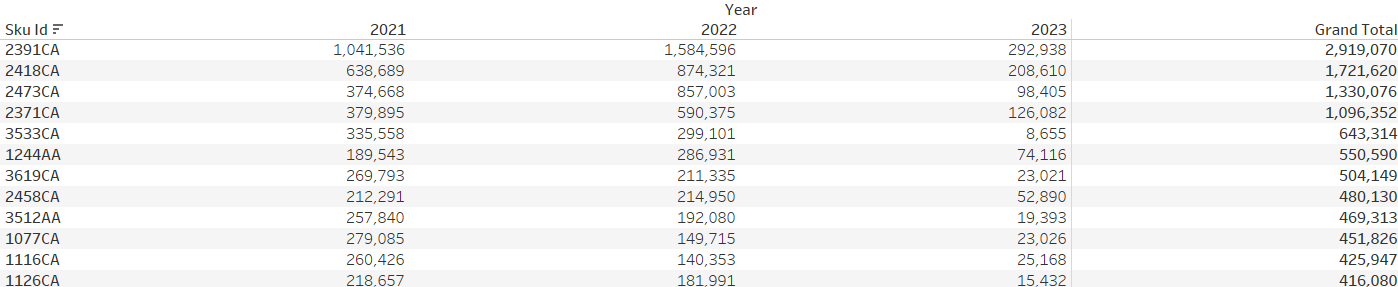

In [40]:
print(final_df['SKU ID'].unique)
sku_list = ['2418CA','2473CA','3533CA','2391CA','2371CA']
print(sku_list)
sel_df = final_df[final_df['SKU ID'].isin(sku_list)].reset_index(drop=True)
print(sel_df)

<bound method Series.unique of 0        1009AA
1        1009AA
2        1077CA
3        1077CA
4        1083AA
          ...  
11968    3579CA
11969    3590BA
11970    3610AA
11971    3616CA
11972    3619CA
Name: SKU ID, Length: 11973, dtype: object>
['2418CA', '2473CA', '3533CA', '2391CA', '2371CA']
     Year  Month  SKU ID  Order Quantity Tranc_Mth_Yr  Unit Sale Price  \
0    2021      1  2371CA        0.000000   2021-01-01          3.44000   
1    2021      1  2391CA        0.000000   2021-01-01          0.75915   
2    2021      1  2418CA        0.000000   2021-01-01          5.80000   
3    2021      1  2473CA        0.000000   2021-01-01          5.95000   
4    2021      1  3533CA    21201.000000   2021-01-01          0.64377   
..    ...    ...     ...             ...          ...              ...   
234  2023      7  2391CA     6344.577089   2023-07-01          0.75915   
235  2023      7  2391CA     6344.577089   2023-07-01          0.75915   
236  2023      7  2418CA    1853

In [41]:
sel_df.to_csv('Top_2.csv', index = False)

In [42]:
# Step 1: Identify only rows where Order Quantity is zero
zero_qty_mask = sel_df['Order Quantity'] == 0

# Step 2: Compute average (non-zero) Order Quantity for each SKU ID and Year
avg_consumption = (
    sel_df[sel_df['Order Quantity'] > 0]
    .groupby(['SKU ID', 'Year'])['Order Quantity']
    .mean()
    .rename('Avg_Consumption')
    .reset_index()
)

print(avg_consumption)

    SKU ID  Year  Avg_Consumption
0   2371CA  2021     55821.857689
1   2371CA  2022     50626.394374
2   2371CA  2023     17744.280942
3   2391CA  2021    142564.075501
4   2391CA  2022    131825.782622
5   2391CA  2023     45575.495608
6   2418CA  2021     70867.107016
7   2418CA  2022     74583.956595
8   2418CA  2023     34712.442827
9   2473CA  2021     54311.946379
10  2473CA  2022     72997.792574
11  2473CA  2023     21097.511975
12  3533CA  2021     29064.052632
13  3533CA  2022     27250.736842
14  3533CA  2023      1293.571429


In [43]:
# Step 3: Merge this average back into the original DataFrame (only adds values where matched)
sel_df = sel_df.merge(avg_consumption, on=['SKU ID', 'Year'], how='left')

print(sel_df)

     Year  Month  SKU ID  Order Quantity Tranc_Mth_Yr  Unit Sale Price  \
0    2021      1  2371CA        0.000000   2021-01-01          3.44000   
1    2021      1  2391CA        0.000000   2021-01-01          0.75915   
2    2021      1  2418CA        0.000000   2021-01-01          5.80000   
3    2021      1  2473CA        0.000000   2021-01-01          5.95000   
4    2021      1  3533CA    21201.000000   2021-01-01          0.64377   
..    ...    ...     ...             ...          ...              ...   
234  2023      7  2391CA     6344.577089   2023-07-01          0.75915   
235  2023      7  2391CA     6344.577089   2023-07-01          0.75915   
236  2023      7  2418CA    18537.415377   2023-07-01          5.80000   
237  2023      7  2473CA    20568.655062   2023-07-01          5.95000   
238  2023      7  3533CA      200.000000   2023-07-01          0.64377   

       Vendor Name  Holiday_Indicator  Cost per SKU  Average Lead Time (days)  \
0       Cixi Group            

In [44]:
# Step 4: Fill zero Order Quantity ONLY with average consumption (leave others unchanged)
sel_df.loc[zero_qty_mask, 'Order Quantity'] = sel_df.loc[zero_qty_mask, 'Avg_Consumption']

# Step 5: Drop helper column if no longer needed
sel_df.drop(columns='Avg_Consumption', inplace=True)

In [45]:
print(sel_df)

     Year  Month  SKU ID  Order Quantity Tranc_Mth_Yr  Unit Sale Price  \
0    2021      1  2371CA    55821.857689   2021-01-01          3.44000   
1    2021      1  2391CA   142564.075501   2021-01-01          0.75915   
2    2021      1  2418CA    70867.107016   2021-01-01          5.80000   
3    2021      1  2473CA    54311.946379   2021-01-01          5.95000   
4    2021      1  3533CA    21201.000000   2021-01-01          0.64377   
..    ...    ...     ...             ...          ...              ...   
234  2023      7  2391CA     6344.577089   2023-07-01          0.75915   
235  2023      7  2391CA     6344.577089   2023-07-01          0.75915   
236  2023      7  2418CA    18537.415377   2023-07-01          5.80000   
237  2023      7  2473CA    20568.655062   2023-07-01          5.95000   
238  2023      7  3533CA      200.000000   2023-07-01          0.64377   

       Vendor Name  Holiday_Indicator  Cost per SKU  Average Lead Time (days)  \
0       Cixi Group            

In [46]:
sel_df.to_csv('Top_2_Clean.csv', index = False)

In [47]:
sel_df.dtypes

Year                                 int32
Month                                int32
SKU ID                              object
Order Quantity                     float64
Tranc_Mth_Yr                datetime64[ns]
Unit Sale Price                    float64
Vendor Name                         object
Holiday_Indicator                    int64
Cost per SKU                       float64
Average Lead Time (days)             int64
Maximum Lead Time (days)             int64
dtype: object

**Train data based on the different year**

In [49]:
train_year = [2021,2022,2023]
train_set = sel_df[sel_df['Year'].isin(train_year)].reset_index(drop=True)
print(f'Train: {train_set}')

Train:      Year  Month  SKU ID  Order Quantity Tranc_Mth_Yr  Unit Sale Price  \
0    2021      1  2371CA    55821.857689   2021-01-01          3.44000   
1    2021      1  2391CA   142564.075501   2021-01-01          0.75915   
2    2021      1  2418CA    70867.107016   2021-01-01          5.80000   
3    2021      1  2473CA    54311.946379   2021-01-01          5.95000   
4    2021      1  3533CA    21201.000000   2021-01-01          0.64377   
..    ...    ...     ...             ...          ...              ...   
234  2023      7  2391CA     6344.577089   2023-07-01          0.75915   
235  2023      7  2391CA     6344.577089   2023-07-01          0.75915   
236  2023      7  2418CA    18537.415377   2023-07-01          5.80000   
237  2023      7  2473CA    20568.655062   2023-07-01          5.95000   
238  2023      7  3533CA      200.000000   2023-07-01          0.64377   

       Vendor Name  Holiday_Indicator  Cost per SKU  Average Lead Time (days)  \
0       Cixi Group     

## Import Libraries for ARIMA Modelling

In [50]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

import pmdarima as pm
auto_model = pm.auto_arima(
    ts,
    seasonal=True, m=12,
    stepwise=True,            # faster
    information_criterion='aic',
    max_p=3, max_q=3, max_P=2, max_Q=2,
    d=None, D=None,           # let it test differencing
    trace=True
)
print(auto_model.summary())

### For Loop for multiple SKU ID forecast prediction

D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegress

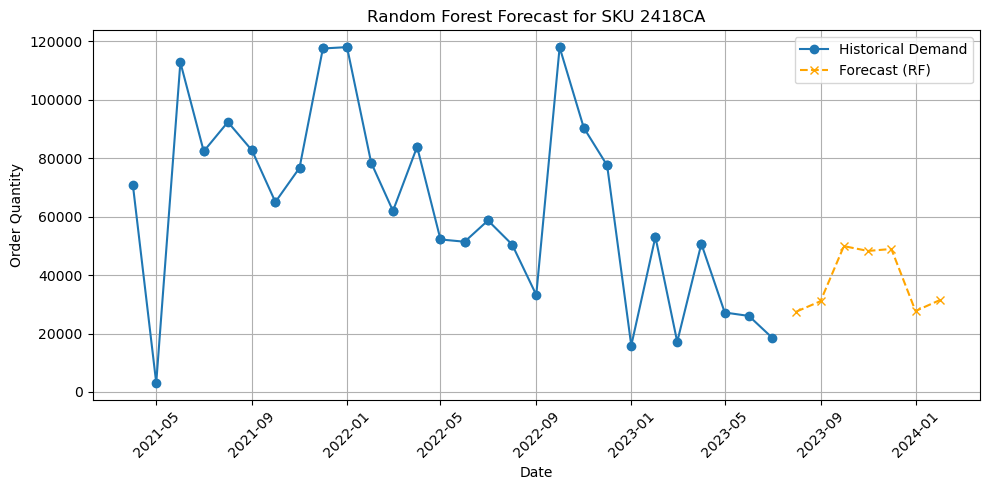

D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegress

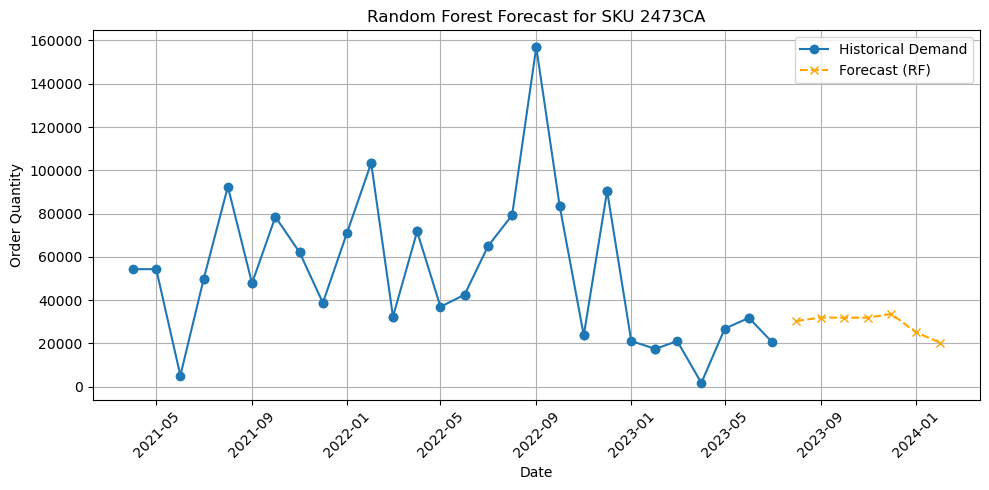

D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegress

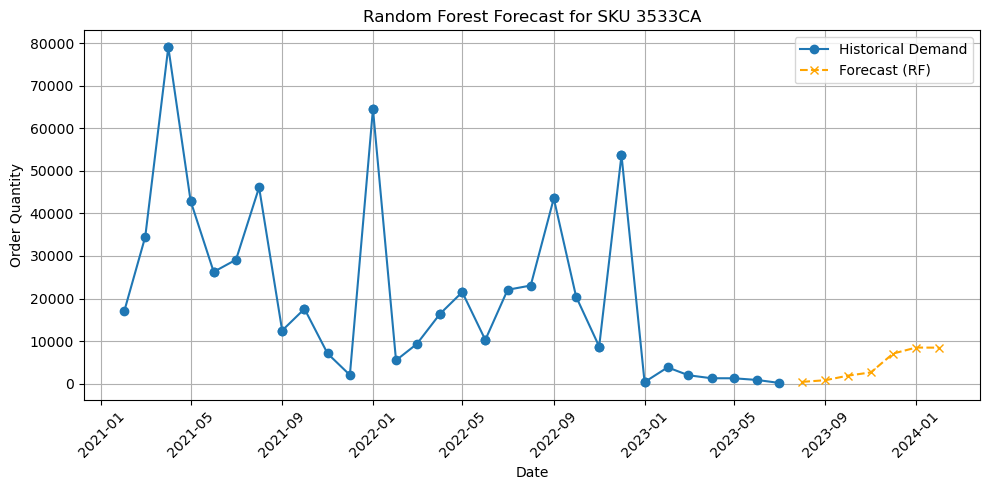

D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegress

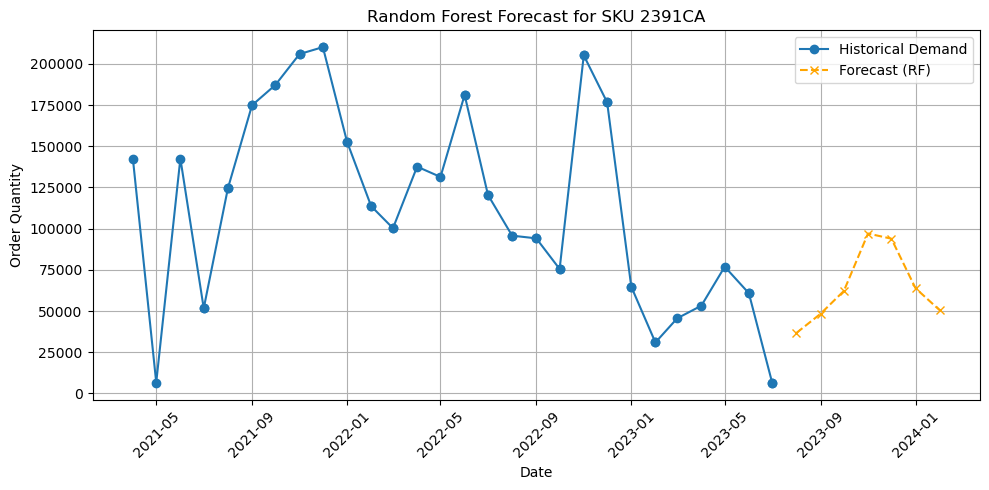

D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegress

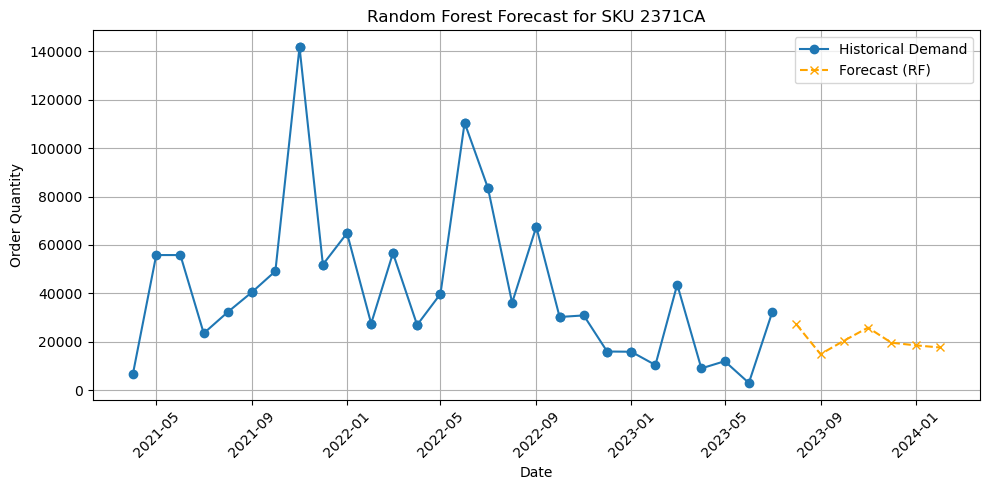

In [84]:
#Random Forest Prediction
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Define number of forecast steps and lag features
forecast_steps = 7
n_lags = 3

forecast_results_rf = []

for sku in sku_list:
    df_sku = sel_df[sel_df['SKU ID'] == sku].copy().sort_values('Tranc_Mth_Yr')
    
    # Create lag features
    for lag in range(1, n_lags + 1):
        df_sku[f'lag_{lag}'] = df_sku['Order Quantity'].shift(lag)

    # Drop rows with missing lags
    df_sku.dropna(inplace=True)
    
    # Create features and target
    feature_cols = [f'lag_{i}' for i in range(1, n_lags + 1)] + ['Month', 'Year']
    X = df_sku[feature_cols]
    y = df_sku['Order Quantity']

    # Train/test split
    train_mask = df_sku['Year'].isin(train_year)
    X_train, y_train = X[train_mask], y[train_mask]

    # Fit the model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Start forecasting
    last_known = df_sku.iloc[-1:].copy()
    forecast_values = []
    forecast_dates = []

    for step in range(1, forecast_steps + 1):
        next_month = pd.to_datetime(last_known['Tranc_Mth_Yr'].values[0]) + pd.DateOffset(months=1)
      #  next_month = last_known['Tranc_Mth_Yr'].values[0] + np.timedelta64(1, 'M')
        year = pd.to_datetime(next_month).year
        month = pd.to_datetime(next_month).month

        input_data = last_known[[f'lag_{i}' for i in range(1, n_lags + 1)]].values.flatten().tolist()
        input_data += [month, year]

        pred = model.predict([input_data])[0]
        forecast_values.append(pred)
        forecast_dates.append(pd.to_datetime(next_month))

        # Update last_known for next iteration
        new_row = last_known.copy()
        new_row['Tranc_Mth_Yr'] = next_month
        for i in range(n_lags, 1, -1):
            new_row[f'lag_{i}'] = new_row[f'lag_{i - 1}']
        new_row['lag_1'] = pred
        last_known = new_row

    # Collect results
    forecast_results_rf.append({
        'SKU ID': sku,
        'Forecast': forecast_values,
        'Forecast_Dates': forecast_dates
    })

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(df_sku['Tranc_Mth_Yr'], df_sku['Order Quantity'], marker='o', label='Historical Demand')
    plt.plot(forecast_dates, forecast_values, marker='x', linestyle='--', color='orange', label='Forecast (RF)')
    plt.title(f'Random Forest Forecast for SKU {sku}')
    plt.xlabel('Date')
    plt.ylabel('Order Quantity')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

['lag_1', 'lag_2', 'lag_3', 'Month', 'Year']
Training range for SKU 2418CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2418CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2418CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00


D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegress

Training range for SKU 2418CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2418CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2418CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2418CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00


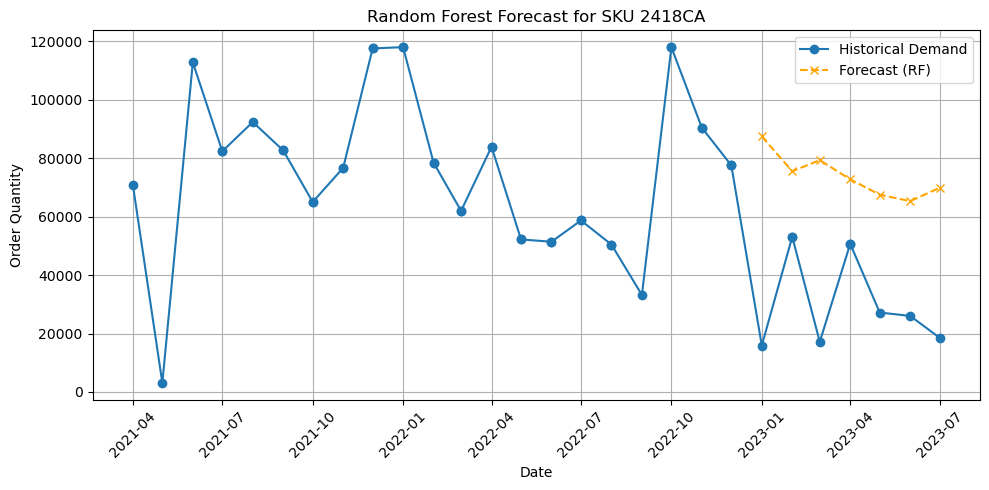

['lag_1', 'lag_2', 'lag_3', 'Month', 'Year']


D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegress

Training range for SKU 2473CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2473CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2473CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2473CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2473CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2473CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2473CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00


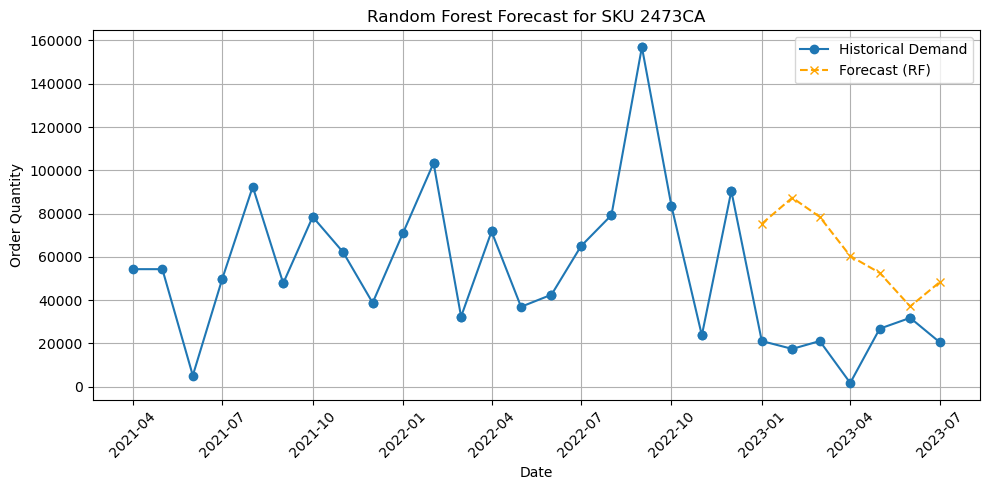

['lag_1', 'lag_2', 'lag_3', 'Month', 'Year']


D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegress

Training range for SKU 3533CA: 2021-02-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 3533CA: 2021-02-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 3533CA: 2021-02-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 3533CA: 2021-02-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 3533CA: 2021-02-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 3533CA: 2021-02-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 3533CA: 2021-02-01 00:00:00 to 2022-12-01 00:00:00


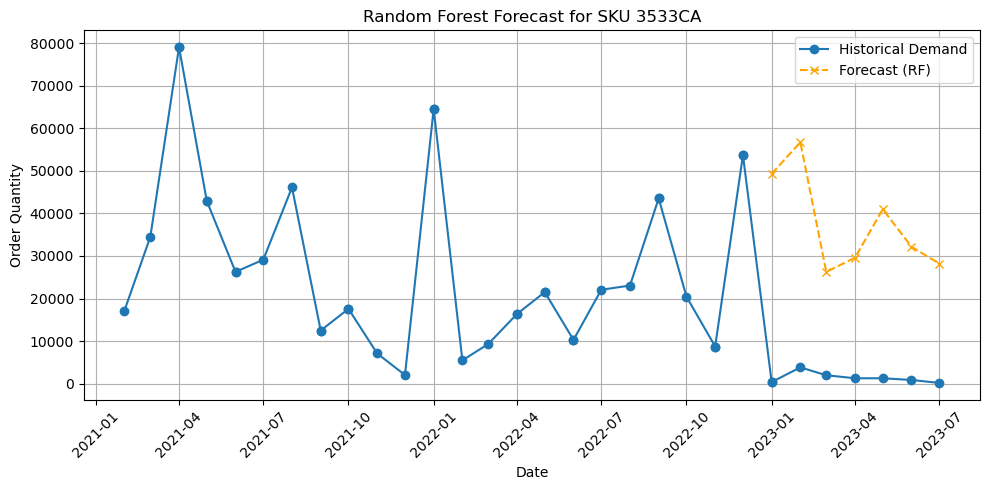

['lag_1', 'lag_2', 'lag_3', 'Month', 'Year']


D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegress

Training range for SKU 2391CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2391CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2391CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2391CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2391CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2391CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2391CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00


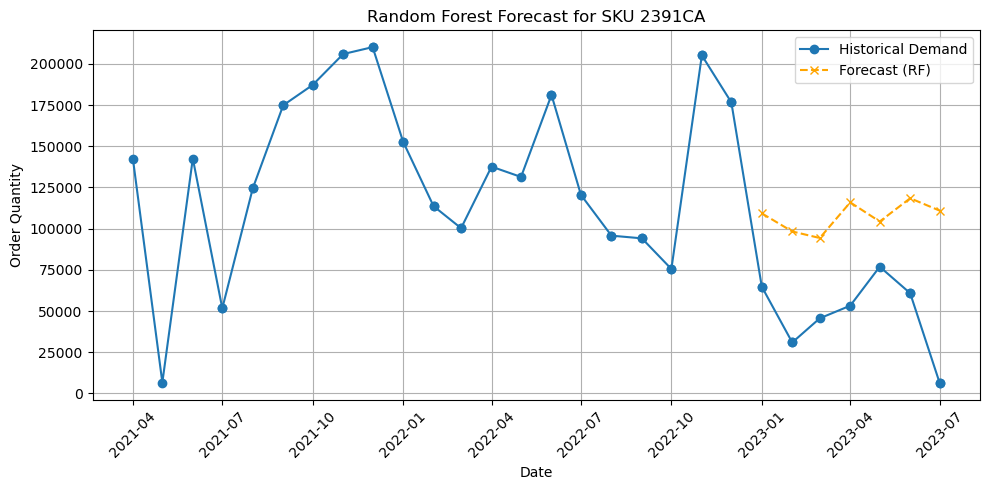

['lag_1', 'lag_2', 'lag_3', 'Month', 'Year']


D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegress

Training range for SKU 2371CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2371CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2371CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2371CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2371CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2371CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00
Training range for SKU 2371CA: 2021-04-01 00:00:00 to 2022-12-01 00:00:00


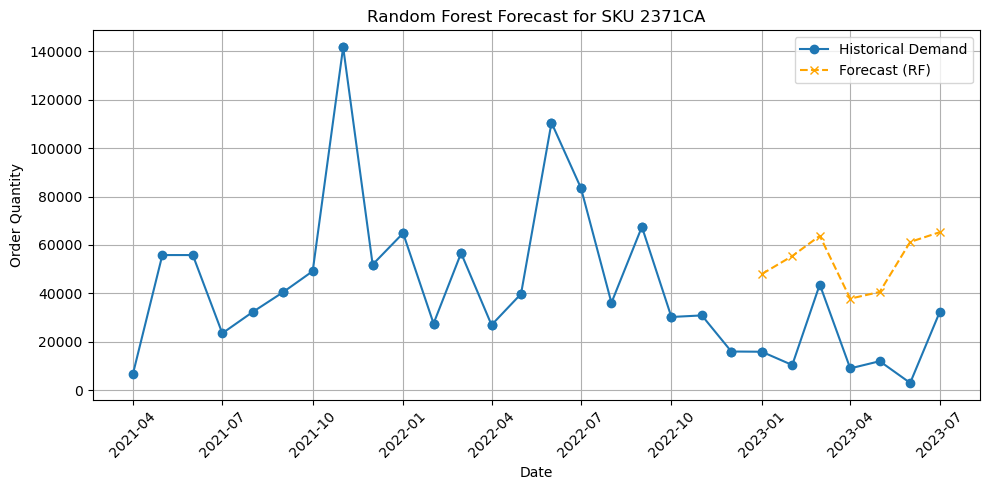

In [93]:
#Random Forest Prediction
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Define number of forecast steps and lag features
forecast_steps = 7
n_lags = 3
train_year = [2021,2022]

forecast_results_rf = []

for sku in sku_list:
    df_sku = sel_df[sel_df['SKU ID'] == sku].copy().sort_values('Tranc_Mth_Yr')
    
    # Create lag features
    for lag in range(1, n_lags + 1):
        df_sku[f'lag_{lag}'] = df_sku['Order Quantity'].shift(lag)

    # Drop rows with missing lags
    df_sku.dropna(inplace=True)
    
    # Create features and target
    feature_cols = [f'lag_{i}' for i in range(1, n_lags + 1)] + ['Month', 'Year']
    X = df_sku[feature_cols]
    y = df_sku['Order Quantity']
    print(feature_cols)
    # Train/test split
    train_mask = df_sku['Year'].isin(train_year)
    X_train, y_train = X[train_mask], y[train_mask]

    # Fit the model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Start forecasting from Jan 2023 to Jul 2023
    start_forecast_date = pd.Timestamp("2023-01-01")
    end_forecast_date = pd.Timestamp("2023-07-01")
    current_forecast_date = start_forecast_date

    # Use the last available row in df_sku to start forecasting
    last_known = df_sku.iloc[-1:].copy()
    forecast_values = []
    forecast_dates = []

    while current_forecast_date <= end_forecast_date:
        year = current_forecast_date.year
        month = current_forecast_date.month

        # Prepare input with lag features
        input_data = last_known[[f'lag_{i}' for i in range(1, n_lags + 1)]].values.flatten().tolist()
        input_data += [month, year]

        # Make prediction
        pred = model.predict([input_data])[0]
        forecast_values.append(pred)
        forecast_dates.append(current_forecast_date)

        # Update for next step
        new_row = last_known.copy()
        new_row['Tranc_Mth_Yr'] = current_forecast_date
        for i in range(n_lags, 1, -1):
            new_row[f'lag_{i}'] = new_row[f'lag_{i - 1}']
        new_row['lag_1'] = pred
        last_known = new_row

        # Increment month
        current_forecast_date += pd.DateOffset(months=1)
        print(f"Training range for SKU {sku}: {df_sku[train_mask]['Tranc_Mth_Yr'].min()} to {df_sku[train_mask]['Tranc_Mth_Yr'].max()}")

    # Collect results
    forecast_results_rf.append({
        'SKU ID': sku,
        'Forecast': forecast_values,
        'Forecast_Dates': forecast_dates
    })

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(df_sku['Tranc_Mth_Yr'], df_sku['Order Quantity'], marker='o', label='Historical Demand')
    plt.plot(forecast_dates, forecast_values, marker='x', linestyle='--', color='orange', label='Forecast (RF)')
    plt.title(f'Random Forest Forecast for SKU {sku}')
    plt.xlabel('Date')
    plt.ylabel('Order Quantity')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\anaconda

2418CA,Average Lead Time (days)    60
Maximum Lead Time (days)    85
Name: 2, dtype: int64 {1.9710906701708277} {2.7923784494086727}


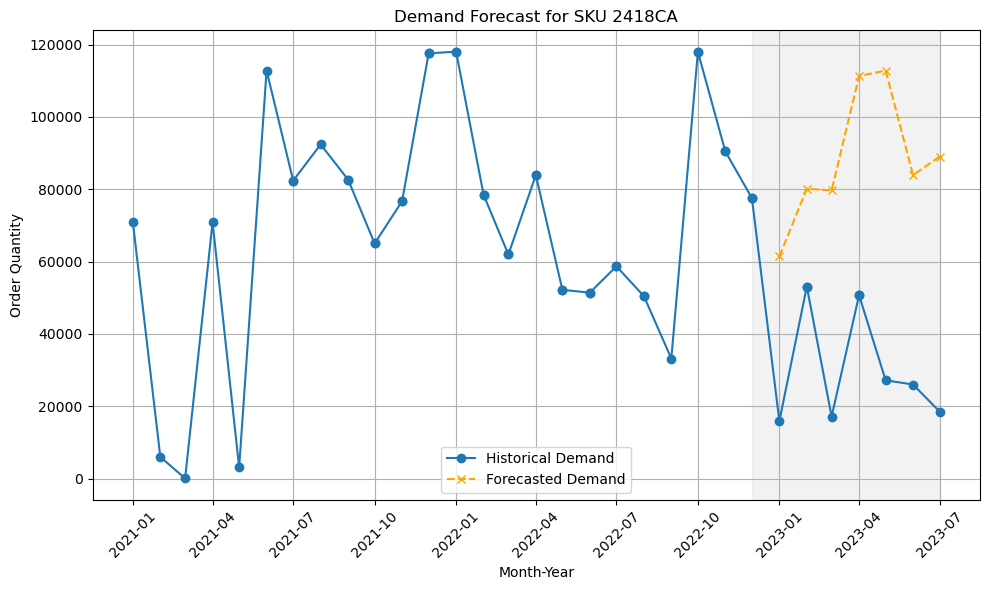

D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\anaconda

2473CA,Average Lead Time (days)    60
Maximum Lead Time (days)    92
Name: 3, dtype: int64 {1.9710906701708277} {3.0223390275952693}


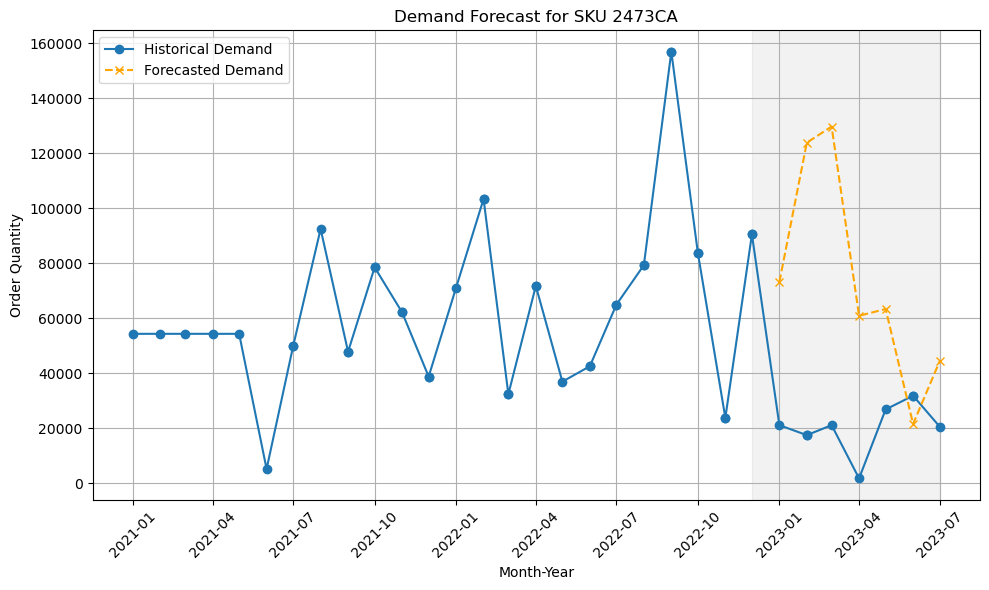

D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\anaconda

3533CA,Average Lead Time (days)    40
Maximum Lead Time (days)    64
Name: 4, dtype: int64 {1.314060446780552} {2.102496714848883}


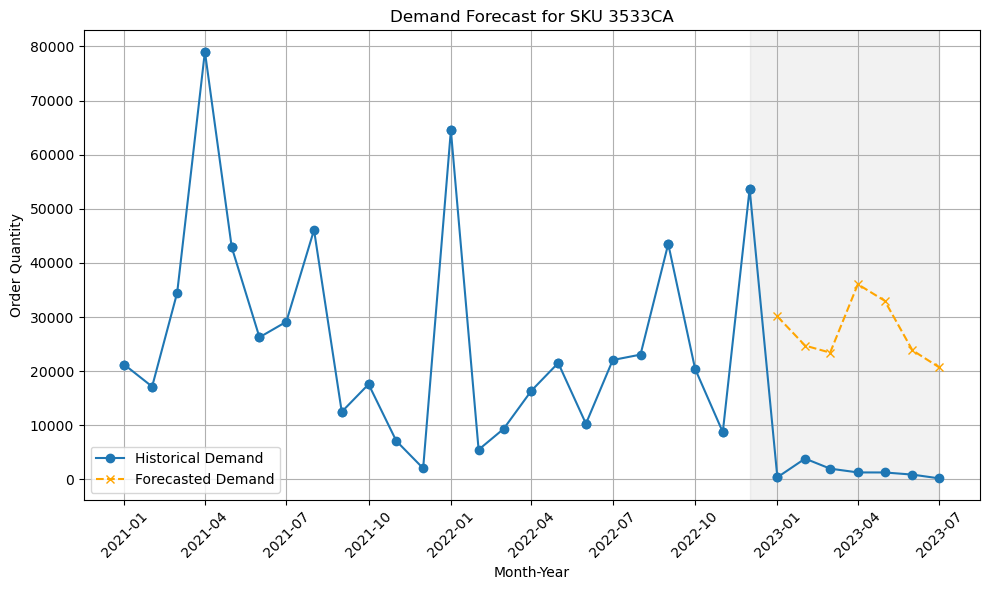

D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\anaconda

2391CA,Average Lead Time (days)    45
Maximum Lead Time (days)    67
Name: 1, dtype: int64 {1.4783180026281209} {2.2010512483574245}


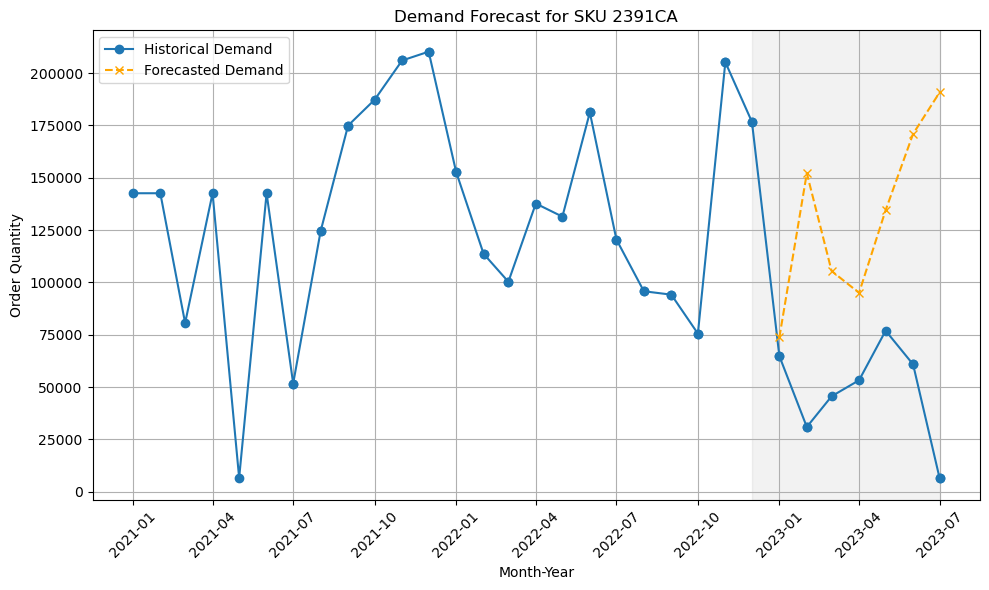

D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\anaconda

2371CA,Average Lead Time (days)     90
Maximum Lead Time (days)    136
Name: 0, dtype: int64 {2.9566360052562417} {4.467805519053877}


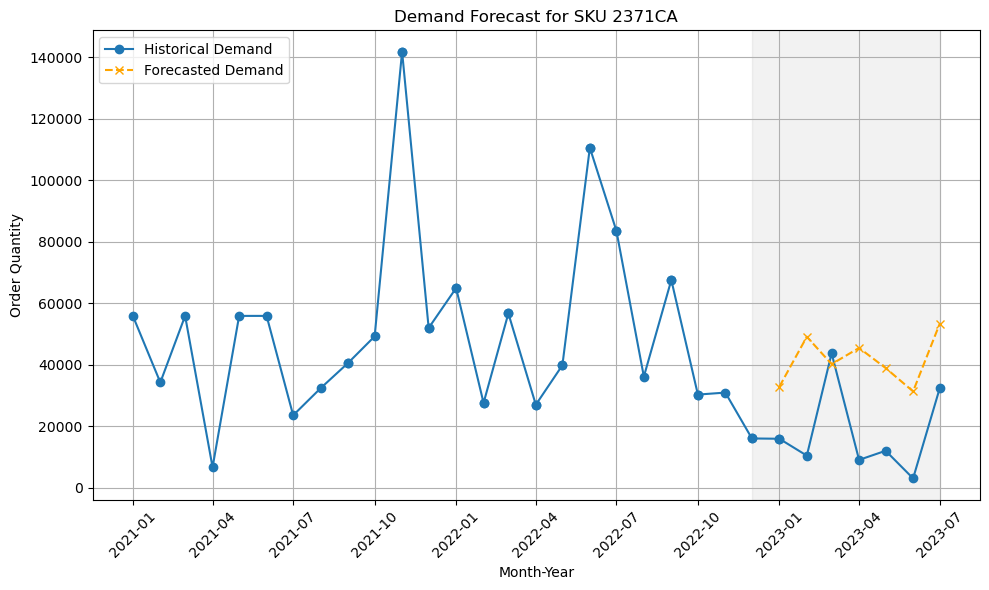

   SKU ID                                     Forecast_Dates  \
0  2418CA  [2023-01-01 00:00:00, 2023-02-01 00:00:00, 202...   
1  2473CA  [2023-01-01 00:00:00, 2023-02-01 00:00:00, 202...   
2  3533CA  [2023-01-01 00:00:00, 2023-02-01 00:00:00, 202...   
3  2391CA  [2023-01-01 00:00:00, 2023-02-01 00:00:00, 202...   
4  2371CA  [2023-01-01 00:00:00, 2023-02-01 00:00:00, 202...   

                                            Forecast  Avg_Lead_Time_Months  \
0  [61431.076011947625, 80137.50938338554, 79675....              1.971091   
1  [73128.16477190197, 123831.58400270616, 129679...              1.971091   
2  [30114.446619633058, 24734.28155023377, 23431....              1.314060   
3  [73678.02741513234, 152144.58722190888, 105405...              1.478318   
4  [32794.98459232735, 49045.77763390337, 40143.5...              2.956636   

   Max_Lead_Time_Months  
0              2.792378  
1              3.022339  
2              2.102497  
3              2.201051  
4              4

In [128]:
# Define SKUs to forecast

    
forecast_steps = 7

# Store forecast + lead time calculations
forecast_results = []


#train_set = sel_df[sel_df['Year'].isin(train_year)].reset_index(drop=True)

for sku in sku_list:
    # Full historical data for plotting
    historical_data = sel_df[sel_df['SKU ID'] == sku].set_index('Tranc_Mth_Yr')['Order Quantity']

    # Training data
    ts = train_set[train_set['SKU ID'] == sku].set_index('Tranc_Mth_Yr')['Order Quantity']
    ts= ts[ts.index < pd.Timestamp('2023-01-01')]
    
    # Skip if not enough data points
    if len(ts) < 12:
        print(f"Skipping SKU {sku} due to insufficient training data.")
        continue

    # SARIMA model (tune as needed)
    try:
        model = SARIMAX(ts, order=(0, 0, 2), seasonal_order=(0, 1, 11, 9))
        results = model.fit(disp=False)
        forecast = results.forecast(steps=forecast_steps)
    except Exception as e:
        print(f"Model failed for SKU {sku}: {e}")
        continue

    # Generate forecast index
    forecast_index = pd.date_range(start=ts.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='MS') #MS = Month Start, #period = How many months to plot 
    forecast_series = pd.Series(forecast.values, index=forecast_index)

    # Lead time info for this SKU
    lead_time_info = sel_df[sel_df['SKU ID'] == sku][['Average Lead Time (days)', 'Maximum Lead Time (days)']].iloc[0]
    avg_lead_time_months = lead_time_info['Average Lead Time (days)'] / 30.44
    max_lead_time_months = lead_time_info['Maximum Lead Time (days)'] / 30.44
    print(f'{sku},{lead_time_info}',{avg_lead_time_months},{max_lead_time_months})

    # Demand over lead times
    avg_demand_lead_time = forecast_series[:int(np.ceil(avg_lead_time_months))].mean()
    max_demand_lead_time = forecast_series[:int(np.ceil(avg_lead_time_months))].max()

    # Save results 
    forecast_results.append({
        'SKU ID': sku,
        'Forecast': list(forecast_series.values),
        'Forecast_Dates': list(forecast_series.index),
        'Avg_Lead_Demand': avg_demand_lead_time,
        'Max_Lead_Demand': max_demand_lead_time,
        'Avg_Lead_Time_Months': avg_lead_time_months,
        'Max_Lead_Time_Months': max_lead_time_months
    })

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(historical_data, label='Historical Demand', marker='o')
    plt.plot(forecast_series, label='Forecasted Demand', marker='x', linestyle='--', color='orange')
    plt.axvspan(ts.index[-1], forecast_index[-1], color='gray', alpha=0.1)
    plt.title(f'Demand Forecast for SKU {sku}')
    plt.xlabel('Month-Year')
    plt.ylabel('Order Quantity')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Convert results into DataFrame
forecast_summary_df = pd.DataFrame([
    {
        'SKU ID': item['SKU ID'],
        'Forecast_Dates': item['Forecast_Dates'],
        'Forecast': item['Forecast'],
        'Avg_Lead_Time_Months': item['Avg_Lead_Time_Months'],
        'Max_Lead_Time_Months': item['Max_Lead_Time_Months']
    } for item in forecast_results
])

print(forecast_summary_df)

In [3]:
#XGBoost
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Define number of forecast steps and lag features
forecast_steps = 7
n_lags = 3

forecast_results_xgb = []

for sku in sku_list:
    df_sku = sel_df[sel_df['SKU ID'] == sku].copy().sort_values('Tranc_Mth_Yr')
    
    # Create lag features
    for lag in range(1, n_lags + 1):
        df_sku[f'lag_{lag}'] = df_sku['Order Quantity'].shift(lag)

    # Drop rows with missing lag features
    df_sku.dropna(inplace=True)
    
    # Create features and target
    feature_cols = [f'lag_{i}' for i in range(1, n_lags + 1)] + ['Month', 'Year']
    X = df_sku[feature_cols]
    y = df_sku['Order Quantity']

    # Train/test split
    train_mask = df_sku['Year'].isin(train_year)
    X_train, y_train = X[train_mask], y[train_mask]

    # Fit the XGBoost model
    model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model.fit(X_train, y_train)

    # Start forecasting
    last_known = df_sku.iloc[-1:].copy()
    forecast_values = []
    forecast_dates = []

    for step in range(1, forecast_steps + 1):
        next_month = pd.to_datetime(last_known['Tranc_Mth_Yr'].values[0]) + pd.DateOffset(months=1)
        year = pd.to_datetime(next_month).year
        month = pd.to_datetime(next_month).month

        input_data = last_known[[f'lag_{i}' for i in range(1, n_lags + 1)]].values.flatten().tolist()
        input_data += [month, year]

        # Make prediction
        pred = model.predict([input_data])[0]
        forecast_values.append(pred)
        forecast_dates.append(pd.to_datetime(next_month))

        # Update last_known for next iteration
        new_row = last_known.copy()
        new_row['Tranc_Mth_Yr'] = next_month
        for i in range(n_lags, 1, -1):
            new_row[f'lag_{i}'] = new_row[f'lag_{i - 1}']
        new_row['lag_1'] = pred
        last_known = new_row

    # Store results
    forecast_results_xgb.append({
        'SKU ID': sku,
        'Forecast': forecast_values,
        'Forecast_Dates': forecast_dates
    })

    # Plot results
    plt.figure(figsize=(10, 5))
    plt.plot(df_sku['Tranc_Mth_Yr'], df_sku['Order Quantity'], marker='o', label='Historical Demand')
    plt.plot(forecast_dates, forecast_values, marker='x', linestyle='--', color='green', label='Forecast (XGBoost)')
    plt.title(f'XGBoost Forecast for SKU {sku}')
    plt.xlabel('Date')
    plt.ylabel('Order Quantity')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

NameError: name 'sku_list' is not defined

In [132]:
forecast_summary_df['Forecast_Dates'] = forecast_summary_df['Forecast_Dates'].apply(lambda x: list(x))
forecast_summary_df['Forecast'] = forecast_summary_df['Forecast'].apply(lambda x: list(x))
df_forecast_expanded = forecast_summary_df.explode(['Forecast', 'Forecast_Dates']).reset_index(drop=True)

# Optionally rename columns for clarity:
df_forecast_expanded.rename(columns={
    'Forecast_Dates': 'Forecast_Month',
    'Forecast': 'Forecasted_Demand'
}, inplace=True)

print(df_forecast_expanded)

    SKU ID Forecast_Month Forecasted_Demand  Avg_Lead_Time_Months  \
0   2418CA     2023-01-01      61431.076012              1.971091   
1   2418CA     2023-02-01      80137.509383              1.971091   
2   2418CA     2023-03-01      79675.184126              1.971091   
3   2418CA     2023-04-01     111283.585754              1.971091   
4   2418CA     2023-05-01      112801.81648              1.971091   
5   2418CA     2023-06-01      83892.892856              1.971091   
6   2418CA     2023-07-01      89030.856123              1.971091   
7   2473CA     2023-01-01      73128.164772              1.971091   
8   2473CA     2023-02-01     123831.584003              1.971091   
9   2473CA     2023-03-01     129679.954104              1.971091   
10  2473CA     2023-04-01      60871.089463              1.971091   
11  2473CA     2023-05-01      63330.345269              1.971091   
12  2473CA     2023-06-01      21514.969191              1.971091   
13  2473CA     2023-07-01      443

In [115]:
#print(data_df)
#dataset = data_df.copy()
#print(dataset.columns.tolist)
#subset_3 = dataset.drop(columns = ['Order Number', 'Order Date', 'Warehouse ID', 'Customer Type','Order Quantity','Revenue','Year','Month','Cost per SKU'])
#df_forecast_expanded = df_forecast_expanded.rename(['Forecast_Month']
#df_forecast_expanded = pd.merge (left = df_forecast_expanded, right = subset_3, how = 'left', on = ['SKU ID','Tranc_Mth_Yr'])
#print(df_forecast_expanded)

## To Calculate Safety Stock 

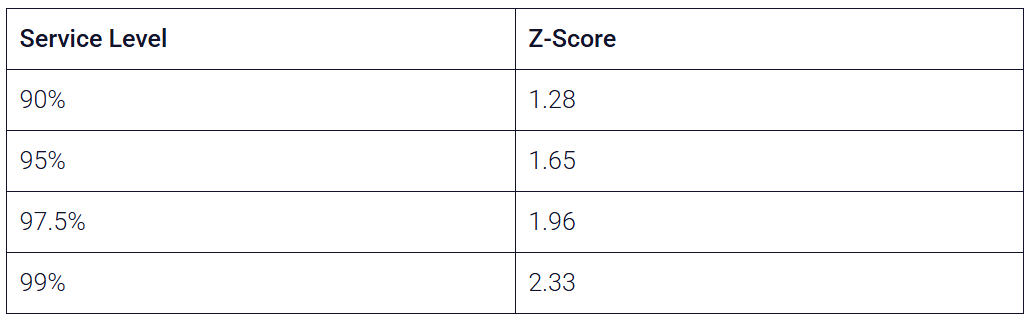

### **Safety Stock formula**
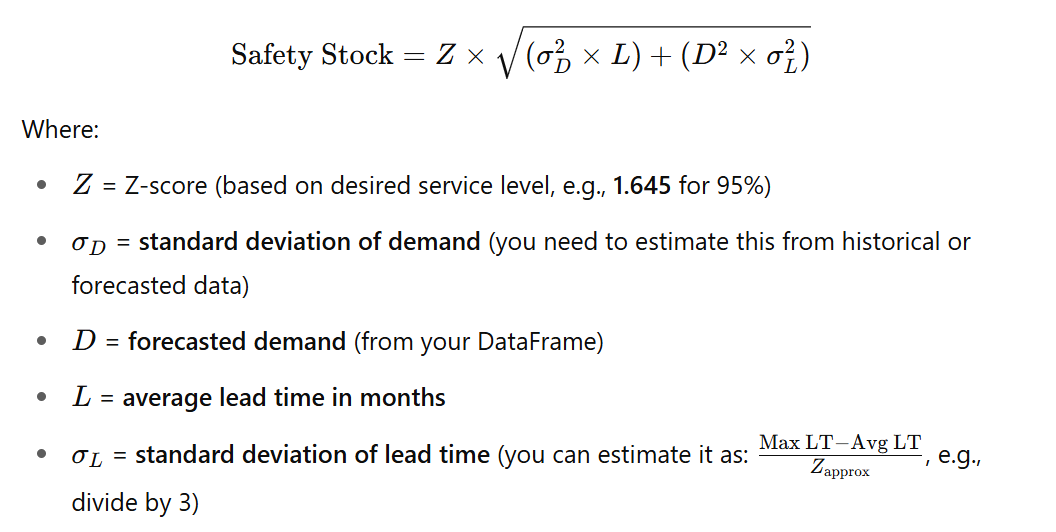

In [146]:
from scipy.stats import norm
import pandas as pd
from datetime import timedelta

# Constants
Z = norm.ppf(0.95)   # 95% service level
Z_approx = 1.732

# SKU-Supplier Map
sku_supplier_map = sel_df.drop_duplicates('SKU ID').set_index('SKU ID')['Vendor Name'].to_dict()
sel_df['Tranc_Mth_Yr'] = pd.to_datetime(sel_df['Tranc_Mth_Yr'])

# Get supplier holidays
holiday_rows = sel_df[sel_df['Holiday_Indicator'] == 1]
supplier_holidays = (
    holiday_rows
    .groupby('Vendor Name')['Tranc_Mth_Yr']
    .unique()
    .apply(lambda x: list(pd.to_datetime(x)))
    .to_dict()
)

# Initialize columns
df_forecast_expanded['Safety_Stock'] = 0.0
df_forecast_expanded['ROP'] = 0.0

# --- Step 1: Calculate FIXED Safety Stock (per SKU) ---
sku_safety_stock_map = {}

for sku in df_forecast_expanded['SKU ID'].unique():
    sku_rows = df_forecast_expanded[df_forecast_expanded['SKU ID'] == sku]
    avg_L_months = sku_rows['Avg_Lead_Time_Months'].iloc[0]
    max_L_months = sku_rows['Max_Lead_Time_Months'].iloc[0]
    forecast_D = sku_rows['Forecasted_Demand'].mean()
    sigma_D = sku_rows['Forecasted_Demand'].std()
    sigma_L = (max_L_months - avg_L_months) / Z_approx
    
    safety_stock = Z * ((sigma_D**2 * avg_L_months + forecast_D**2 * sigma_L**2) ** 0.5)
    sku_safety_stock_map[sku] = safety_stock

# --- Step 2: Adjust ROP per row with holiday-extended lead time ---
for idx, row in df_forecast_expanded.iterrows():
    sku = row['SKU ID']
    forecast_date = pd.to_datetime(row['Forecast_Month'])
    avg_L_months = row['Avg_Lead_Time_Months']
    avg_L_days = int(avg_L_months * 30.44)
    
    supplier = sku_supplier_map.get(sku, None)
    holidays = supplier_holidays.get(supplier, []) if supplier else []
    
    # Weekday holidays within avg lead time window
    lead_time_window = pd.date_range(start=forecast_date, periods=avg_L_days, freq='D')
    weekday_holiday_count = sum(1 for d in holidays if d in lead_time_window and d.weekday() < 5)
    
    adjusted_L_days = avg_L_days + weekday_holiday_count
    adjusted_L_months = adjusted_L_days / 30.44
    
    demand_rate = row['Forecasted_Demand']  # Monthly
    expected_demand_during_lead = demand_rate * adjusted_L_months
    
    safety_stock = sku_safety_stock_map[sku]
    df_forecast_expanded.at[idx, 'Safety_Stock'] = safety_stock
    df_forecast_expanded.at[idx, 'ROP'] = expected_demand_during_lead + safety_stock

print(df_forecast_expanded)

    SKU ID Forecast_Month Forecasted_Demand  Avg_Lead_Time_Months  \
0   2418CA     2023-01-01      61431.076012              1.971091   
1   2418CA     2023-02-01      80137.509383              1.971091   
2   2418CA     2023-03-01      79675.184126              1.971091   
3   2418CA     2023-04-01     111283.585754              1.971091   
4   2418CA     2023-05-01      112801.81648              1.971091   
5   2418CA     2023-06-01      83892.892856              1.971091   
6   2418CA     2023-07-01      89030.856123              1.971091   
7   2473CA     2023-01-01      73128.164772              1.971091   
8   2473CA     2023-02-01     123831.584003              1.971091   
9   2473CA     2023-03-01     129679.954104              1.971091   
10  2473CA     2023-04-01      60871.089463              1.971091   
11  2473CA     2023-05-01      63330.345269              1.971091   
12  2473CA     2023-06-01      21514.969191              1.971091   
13  2473CA     2023-07-01      443

In [142]:
from scipy.stats import norm
import pandas as pd
from datetime import timedelta

# Constants
Z = norm.ppf(0.95)   # 95% service level
Z_approx = 1.732

# Assume supplier_holidays is a dictionary like:
# supplier_holidays = {"SupplierA": [pd.Timestamp("2024-12-25"), pd.Timestamp("2025-01-01")], ...}

# Create new column
df_forecast_expanded['Safety_Stock'] = 0.0

# Build SKU to supplier mapping from sel_df
sku_supplier_map = sel_df.drop_duplicates('SKU ID').set_index('SKU ID')['Vendor Name'].to_dict()
# Ensure Tranc_Mth_Yr is datetime
sel_df['Tranc_Mth_Yr'] = pd.to_datetime(sel_df['Tranc_Mth_Yr'])

# Filter rows where a holiday was flagged
holiday_rows = sel_df[sel_df['Holiday_Indicator'] == 1]

# Group by Vendor Name and collect unique holiday dates
supplier_holidays = (
    holiday_rows
    .groupby('Vendor Name')['Tranc_Mth_Yr']
    .unique()
    .apply(lambda x: list(pd.to_datetime(x)))  # ensure datetime list
    .to_dict()
)

# Loop through each row to compute safety stock with adjusted lead time
for idx, row in df_forecast_expanded.iterrows():
    sku = row['SKU ID']
    forecast_date = pd.to_datetime(row['Forecast_Month'])
    
    # Get lead time in months and convert to days
    avg_L_months = row['Avg_Lead_Time_Months']
    max_L_months = row['Max_Lead_Time_Months']
    avg_L_days = int(avg_L_months * 30.44)
    
    # Get supplier holidays
    supplier = sku_supplier_map.get(sku, None)
    holidays = supplier_holidays.get(supplier, []) if supplier else []
    
    # Calculate weekday-only holiday count within lead time window
    lead_time_window = pd.date_range(start=forecast_date, periods=avg_L_days, freq='D')
    holiday_days = sum(1 for day in holidays if day in lead_time_window and day.weekday() < 5)
    
    # Adjusted lead time in months
    adjusted_L_days = avg_L_days + holiday_days
    adjusted_L_months = adjusted_L_days / 30.44
    
    # Calculate standard deviation of forecast for the SKU
    sku_forecast = df_forecast_expanded[df_forecast_expanded['SKU ID'] == sku]['Forecasted_Demand']
    sigma_D = sku_forecast.std()

    sigma_L = (max_L_months - avg_L_months) / Z_approx
    forecast_D = row['Forecasted_Demand']

    # Final safety stock formula
    safety_stock = Z * ((sigma_D**2 * adjusted_L_months + forecast_D**2 * sigma_L**2) ** 0.5)

    df_forecast_expanded.at[idx, 'Safety_Stock'] = safety_stock

print(df_forecast_expanded)

    SKU ID Forecast_Month Forecasted_Demand  Avg_Lead_Time_Months  \
0   2418CA     2023-01-01      61431.076012              1.971091   
1   2418CA     2023-02-01      80137.509383              1.971091   
2   2418CA     2023-03-01      79675.184126              1.971091   
3   2418CA     2023-04-01     111283.585754              1.971091   
4   2418CA     2023-05-01      112801.81648              1.971091   
5   2418CA     2023-06-01      83892.892856              1.971091   
6   2418CA     2023-07-01      89030.856123              1.971091   
7   2473CA     2023-01-01      73128.164772              1.971091   
8   2473CA     2023-02-01     123831.584003              1.971091   
9   2473CA     2023-03-01     129679.954104              1.971091   
10  2473CA     2023-04-01      60871.089463              1.971091   
11  2473CA     2023-05-01      63330.345269              1.971091   
12  2473CA     2023-06-01      21514.969191              1.971091   
13  2473CA     2023-07-01      443

### ROP Calculation  
ROP=D×L+Safety Stock  
D = Forecasted Average Demand Per Month
L = Average Lead Time In Months



In [162]:
df_forecast_expanded['ROP'] = df_forecast_expanded['Forecasted_Demand'] * df_forecast_expanded['Avg_Lead_Time_Months'] + df_forecast_expanded['Safety_Stock']
print(df_forecast_expanded)

    SKU ID Forecast_Month Forecasted_Demand  Avg_Lead_Time_Months  \
0   2418CA     2023-01-01      52456.340116              1.971091   
1   2418CA     2023-02-01      35374.976706              1.971091   
2   2418CA     2023-03-01      52713.153818              1.971091   
3   2418CA     2023-04-01      63083.906443              1.971091   
4   2418CA     2023-05-01      51265.725782              1.971091   
5   2418CA     2023-06-01      63285.040017              1.971091   
6   2418CA     2023-07-01     104643.152329              1.971091   
7   2473CA     2023-01-01     126812.273228              1.971091   
8   2473CA     2023-02-01      12354.370127              1.971091   
9   2473CA     2023-03-01      49227.445604              1.971091   
10  2473CA     2023-04-01      66731.573504              1.971091   
11  2473CA     2023-05-01      83358.662596              1.971091   
12  2473CA     2023-06-01     173296.585498              1.971091   
13  2473CA     2023-07-01       88